In [1]:
import pandas as pd
import numpy as np

In [2]:
true = pd.read_csv('../data/True.csv')
fake = pd.read_csv('../data/Fake.csv')

In [3]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true['label'] = 1
fake['label'] = 0

In [6]:
news = pd.concat([fake, true], axis=0)

In [7]:
news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [8]:
news.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

## Preprocessing

Keeping the `title` column this time (only dropping `subject` and `date`).

In [9]:
news = news.drop(['subject', 'date'], axis=1)

In [10]:
news = news.sample(frac=1, random_state=42)
news.reset_index(inplace=True)
news.drop('index', axis=1, inplace=True)
news.head()

,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


## Text Cleaning

In [11]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Jayaprakash V
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    # remove html tags
    text = re.sub(r'<.*?>', '', text)
    # remove newline characters
    text = re.sub(r'\n', ' ', text)
    # convert to lowercase
    text = text.lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # remove content inside brackets (like (Reuters), (VIDEO))
    text = re.sub(r'\(.*?\)', '', text)
    # remove non-alphabet characters
    text = re.sub(r'[^a-z\s]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [13]:
news['text'] = news['text'].apply(clean_text)
news['title'] = news['title'].apply(clean_text)

# Combine title + text into a single feature
news['combined'] = news['title'] + ' ' + news['text']
news.head()

,title,text,label,combined
0,ben stein calls th circuit court committed cou...,st century wire says ben stein reputable profe...,0,ben stein calls th circuit court committed cou...
1,trump drops steve bannon national security cou...,washington us president donald trump removed c...,1,trump drops steve bannon national security cou...
2,puerto rico expects us lift jones act shipping...,puerto rico governor ricardo rossello said wed...,1,puerto rico expects us lift jones act shipping...
3,oops trump accidentally confirmed leaked israe...,monday donald trump embarrassed country accide...,0,oops trump accidentally confirmed leaked israe...
4,donald trump heads scotland reopen golf resort,glasgow scotland us presidential candidates go...,1,donald trump heads scotland reopen golf resort...


## Train / Test Split

In [14]:
x = news['combined']   # using title + text
y = news['label']

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print('Train:', x_train.shape, '| Test:', x_test.shape)

Train: (31428,) | Test: (13470,)


## TF-IDF Vectorization

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
xv_train = vectorizer.fit_transform(x_train)
xv_test  = vectorizer.transform(x_test)
print('Train matrix:', xv_train.shape, '| Test matrix:', xv_test.shape)

Train matrix: (31428, 5000) | Test matrix: (13470, 5000)


## Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xv_train, y_train)
y_pred = model.predict(xv_test)
print(f'Logistic Regression Accuracy: {model.score(xv_test, y_test):.4f}')

Logistic Regression Accuracy: 0.9819


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7065
           1       0.98      0.99      0.98      6405

    accuracy                           0.98     13470
   macro avg       0.98      0.98      0.98     13470
weighted avg       0.98      0.98      0.98     13470



## Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(xv_train, y_train)
dt_pred = dt_model.predict(xv_test)
print(f'Decision Tree Accuracy: {dt_model.score(xv_test, y_test):.4f}')

Decision Tree Accuracy: 0.9488


In [20]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7065
           1       0.95      0.94      0.95      6405

    accuracy                           0.95     13470
   macro avg       0.95      0.95      0.95     13470
weighted avg       0.95      0.95      0.95     13470



## Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(xv_train, y_train)
rf_pred = rf_model.predict(xv_test)
print(f'Random Forest Accuracy: {rf_model.score(xv_test, y_test):.4f}')

Random Forest Accuracy: 0.9863


In [22]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7065
           1       0.98      0.99      0.99      6405

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



## Model Comparison (Title + Text)

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
preds  = [y_pred, dt_pred, rf_pred]

results = []
for name, pred in zip(models, preds):
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1 Score':  f1_score(y_test, pred),
    })

comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df.round(4))

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9819     0.9753  0.9869    0.9811
Decision Tree          0.9488     0.9548  0.9368    0.9457
Random Forest          0.9863     0.9831  0.9883    0.9857


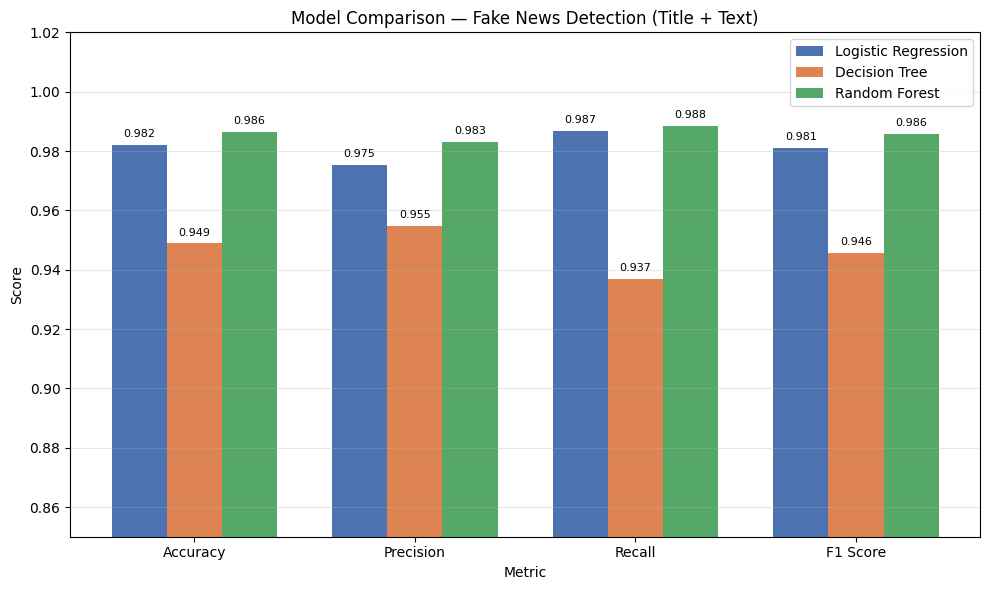

In [24]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x_pos = range(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar([xi + i*width for xi in x_pos], vals, width, label=model_name, color=colors[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Fake News Detection (Title + Text)')
ax.set_xticks([xi + width for xi in x_pos])
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

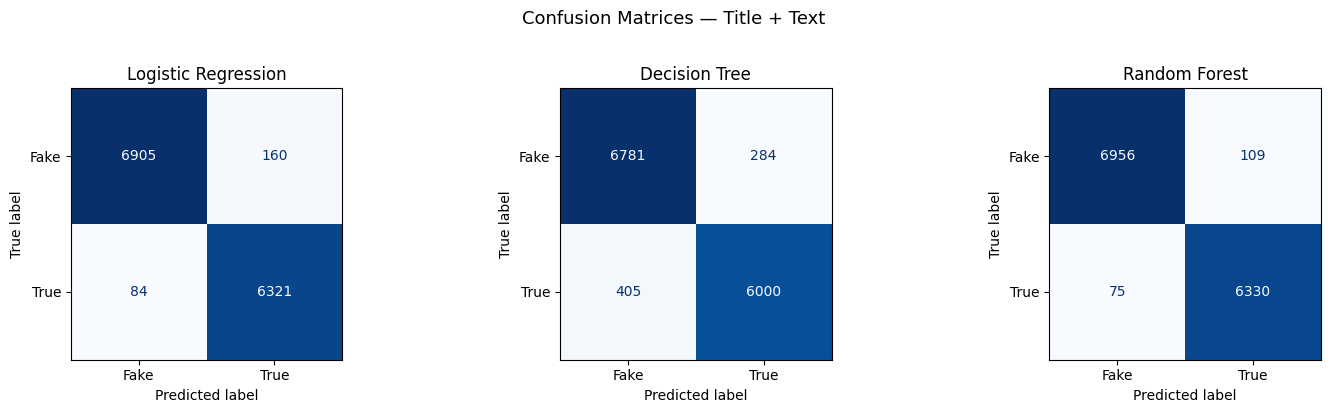

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred in zip(axes, models, preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'True'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Title + Text', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()